In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import plotly.express as px

# !pip install missingno
import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

In [21]:
train_df = pd.read_csv('../data/train_clean.csv')
test_df = pd.read_csv('../data/test_clean.csv')

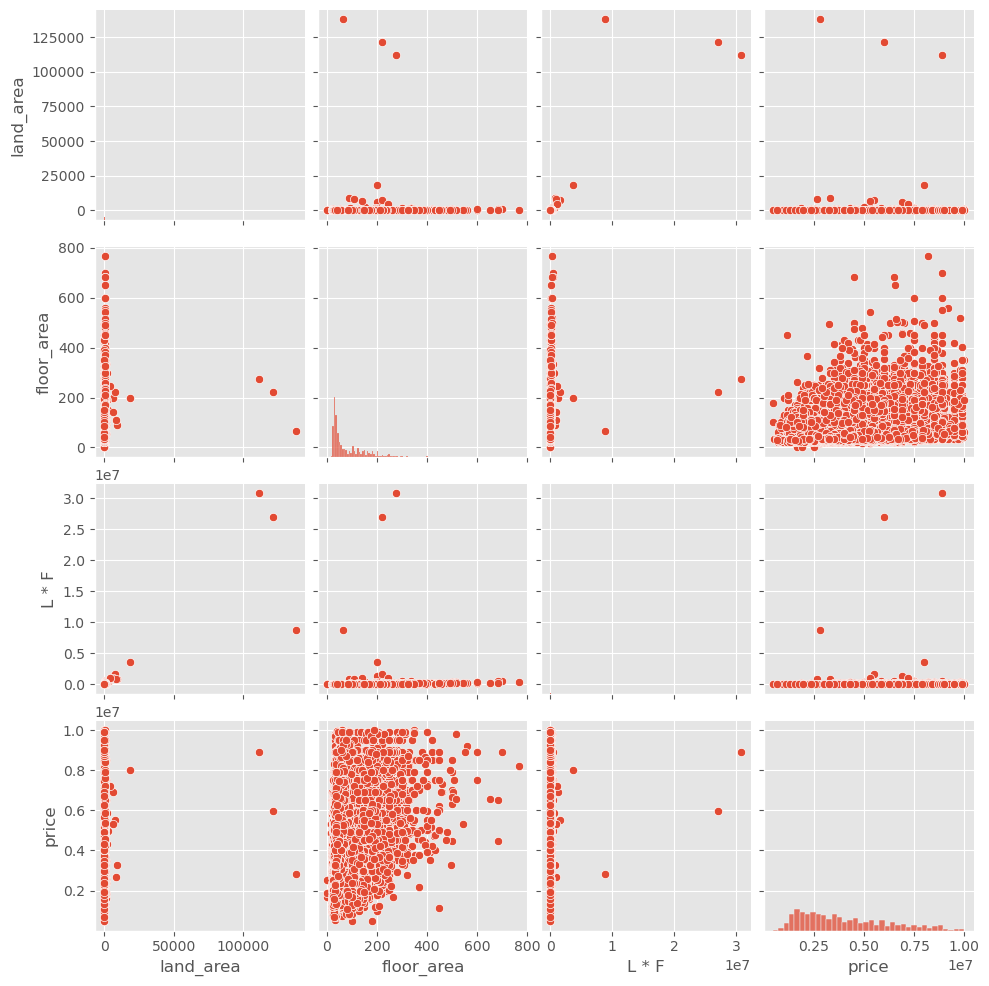

In [67]:
train_df['L * F'] = train_df['land_area'] * train_df['floor_area']

features = [ 'land_area', 'floor_area', 'L * F', 'price'
                            ]

sns.pairplot(train_df[features]);

In [23]:
train_df.head()

,id,province,district,property_type,bedrooms,baths,floor_area,floor_level,land_area,latitude,...,nearby_shops,year_built,facilities,price,is_train,minimum_station_distance,has_security,has_pool,has_sports,has_parking
0,8448321,Bangkok,Watthana,Condo,2.0,2.0,66,10.0,0.0,13.721944,...,20,2011,"['Car Park', 'Community Garden', 'CCTV', 'Fitn...",8500000.0,1,270,1,1,1,1
1,10936325,Bangkok,Watthana,Condo,1.0,1.0,49,8.0,0.0,13.741904,...,20,2012,"['CCTV', 'Fitness corner', '24 hours security'...",5900000.0,1,720,1,1,1,0
2,10927931,Bangkok,Khlong Toei,Condo,1.0,1.0,34,4.0,0.0,13.725395,...,20,2017,"['Car Park', 'Clubhouse', 'Community Garden', ...",6290000.0,1,650,1,1,1,1
3,11004792,Nonthaburi,Bang Kruai,Detached House,3.0,3.0,170,0.0,248.0,13.821687,...,4,0,"['Covered car park', 'Playground', '24 hours s...",8900000.0,1,0,1,1,0,1
4,10757452,Nonthaburi,Mueang Nonthaburi,Townhouse,3.0,2.0,120,0.0,72.0,13.865849,...,15,0,"['Covered car park', '24 hours security']",2390000.0,1,10,1,0,0,1


In [7]:
train_df.columns

Index(['id', 'province', 'district', 'property_type', 'bedrooms', 'baths',
       'floor_area', 'floor_level', 'land_area', 'latitude', 'longitude',
       'nearby_stations', 'nearby_station_distance', 'nearby_bus_stops',
       'nearby_supermarkets', 'nearby_shops', 'year_built', 'facilities',
       'price', 'is_train', 'minimum_station_distance', 'has_security',
       'has_pool', 'has_sports', 'has_parking'],
      dtype='object')

In [25]:
# Prepare your data
features = ['province', 'property_type', 'bedrooms', 'baths', 'floor_area', 'floor_level'
                             , 'land_area','nearby_stations','minimum_station_distance','has_security'
                             ,'has_pool', 'has_sports', 'has_parking'
                            ]

X = pd.get_dummies(train_df[features], 
                   columns=['province', 'property_type'], drop_first=True)
y = train_df['price']

# Split the data
X_train, X_dev, y_train, y_dev = train_test_split(X, y, train_size=0.8, random_state=42)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on development set
y_pred = model.predict(X_dev)

# Evaluate the model
mse = mean_squared_error(y_dev, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 2399050853149.6807


In [27]:
X_test = pd.get_dummies(test_df[features], 
                   columns=['province', 'property_type'], drop_first=True)

In [29]:
pred_test = model.predict(X_test)
pred_test[:10]

array([5036933.16974925, 6671932.21038842, 5494956.91471807,
       3583921.50266933, 3648818.88004267, 5871453.97669713,
       3016581.79300558, 5416353.98106588, 5084011.90456248,
       4038301.79059156])

In [35]:
test_df['price'] = pred_test
test_df[['id','price']].to_csv('../data/submission.csv', index=False)

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

# Prepare your data
features = ['province', 'property_type', 'bedrooms', 'baths', 'floor_area', 'floor_level',
            'land_area', 'nearby_stations', 'minimum_station_distance', 'has_security',
            'has_pool', 'has_sports', 'has_parking']

X = pd.get_dummies(train_df[features], columns=['province', 'property_type'], drop_first=True)
y = train_df['price']

# Split the data
X_train, X_dev, y_train, y_dev = train_test_split(X, y, train_size=0.8, random_state=42)

# Create polynomial features of degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_dev_poly = poly.transform(X_dev)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_dev_scaled = scaler.transform(X_dev_poly)

# Create and fit the Lasso model
model = Lasso(alpha=1.0, max_iter=10000)
model.fit(X_train_scaled, y_train)

# Predict on development set
y_pred = model.predict(X_dev_scaled)

# Evaluate the model
mse = mean_squared_error(y_dev, y_pred)
rmse = np.sqrt(mean_squared_error(y_dev, y_pred))
print(f'Mean Squared Error: {rmse}')


Mean Squared Error: 1372924.900409039


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.061e+16, tolerance: 5.396e+12
  model = cd_fast.enet_coordinate_descent(


In [43]:
# Assuming you have X_test prepared similarly to X_train
# Step 1: Prepare your test data (X_test)
# Make sure X_test has the same features as X_train
X_test = pd.get_dummies(test_df[features], columns=['province', 'property_type'], drop_first=True)

# Align the columns of X_test with X_train, filling any missing columns with 0
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Step 2: Create polynomial features of degree 2 for the test data
X_test_poly = poly.transform(X_test)

# Step 3: Standardize the test features
X_test_scaled = scaler.transform(X_test_poly)

# Step 4: Make predictions using the trained model
y_test_pred = model.predict(X_test_scaled)

# Display predictions
print(y_test_pred)


[4918896.81541378 6346257.02497589 4376129.2956629  ... 3597062.01035458
 1732615.87559392 4653850.11841728]


In [45]:
test_df['price'] = y_test_pred
test_df[['id','price']].to_csv('../data/submission.csv', index=False)

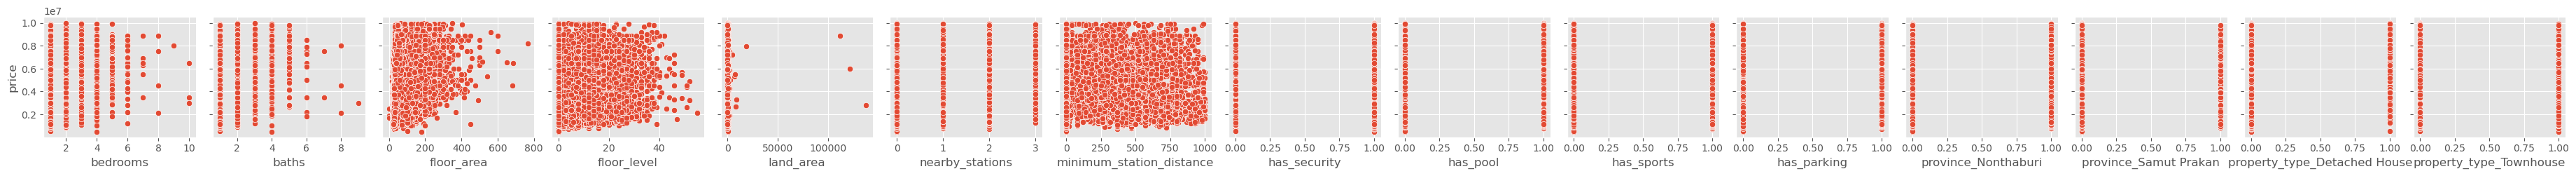

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X_train and y_train into a single DataFrame
train_data = X_train.copy()  # Make a copy of X_train
train_data['price'] = y_train  # Add y_train as a new column

# Use pairplot to visualize the relationships
sns.pairplot(train_data, x_vars=train_data.columns[:-1], y_vars='price')

# Show the plot
plt.show()


KeyboardInterrupt: 

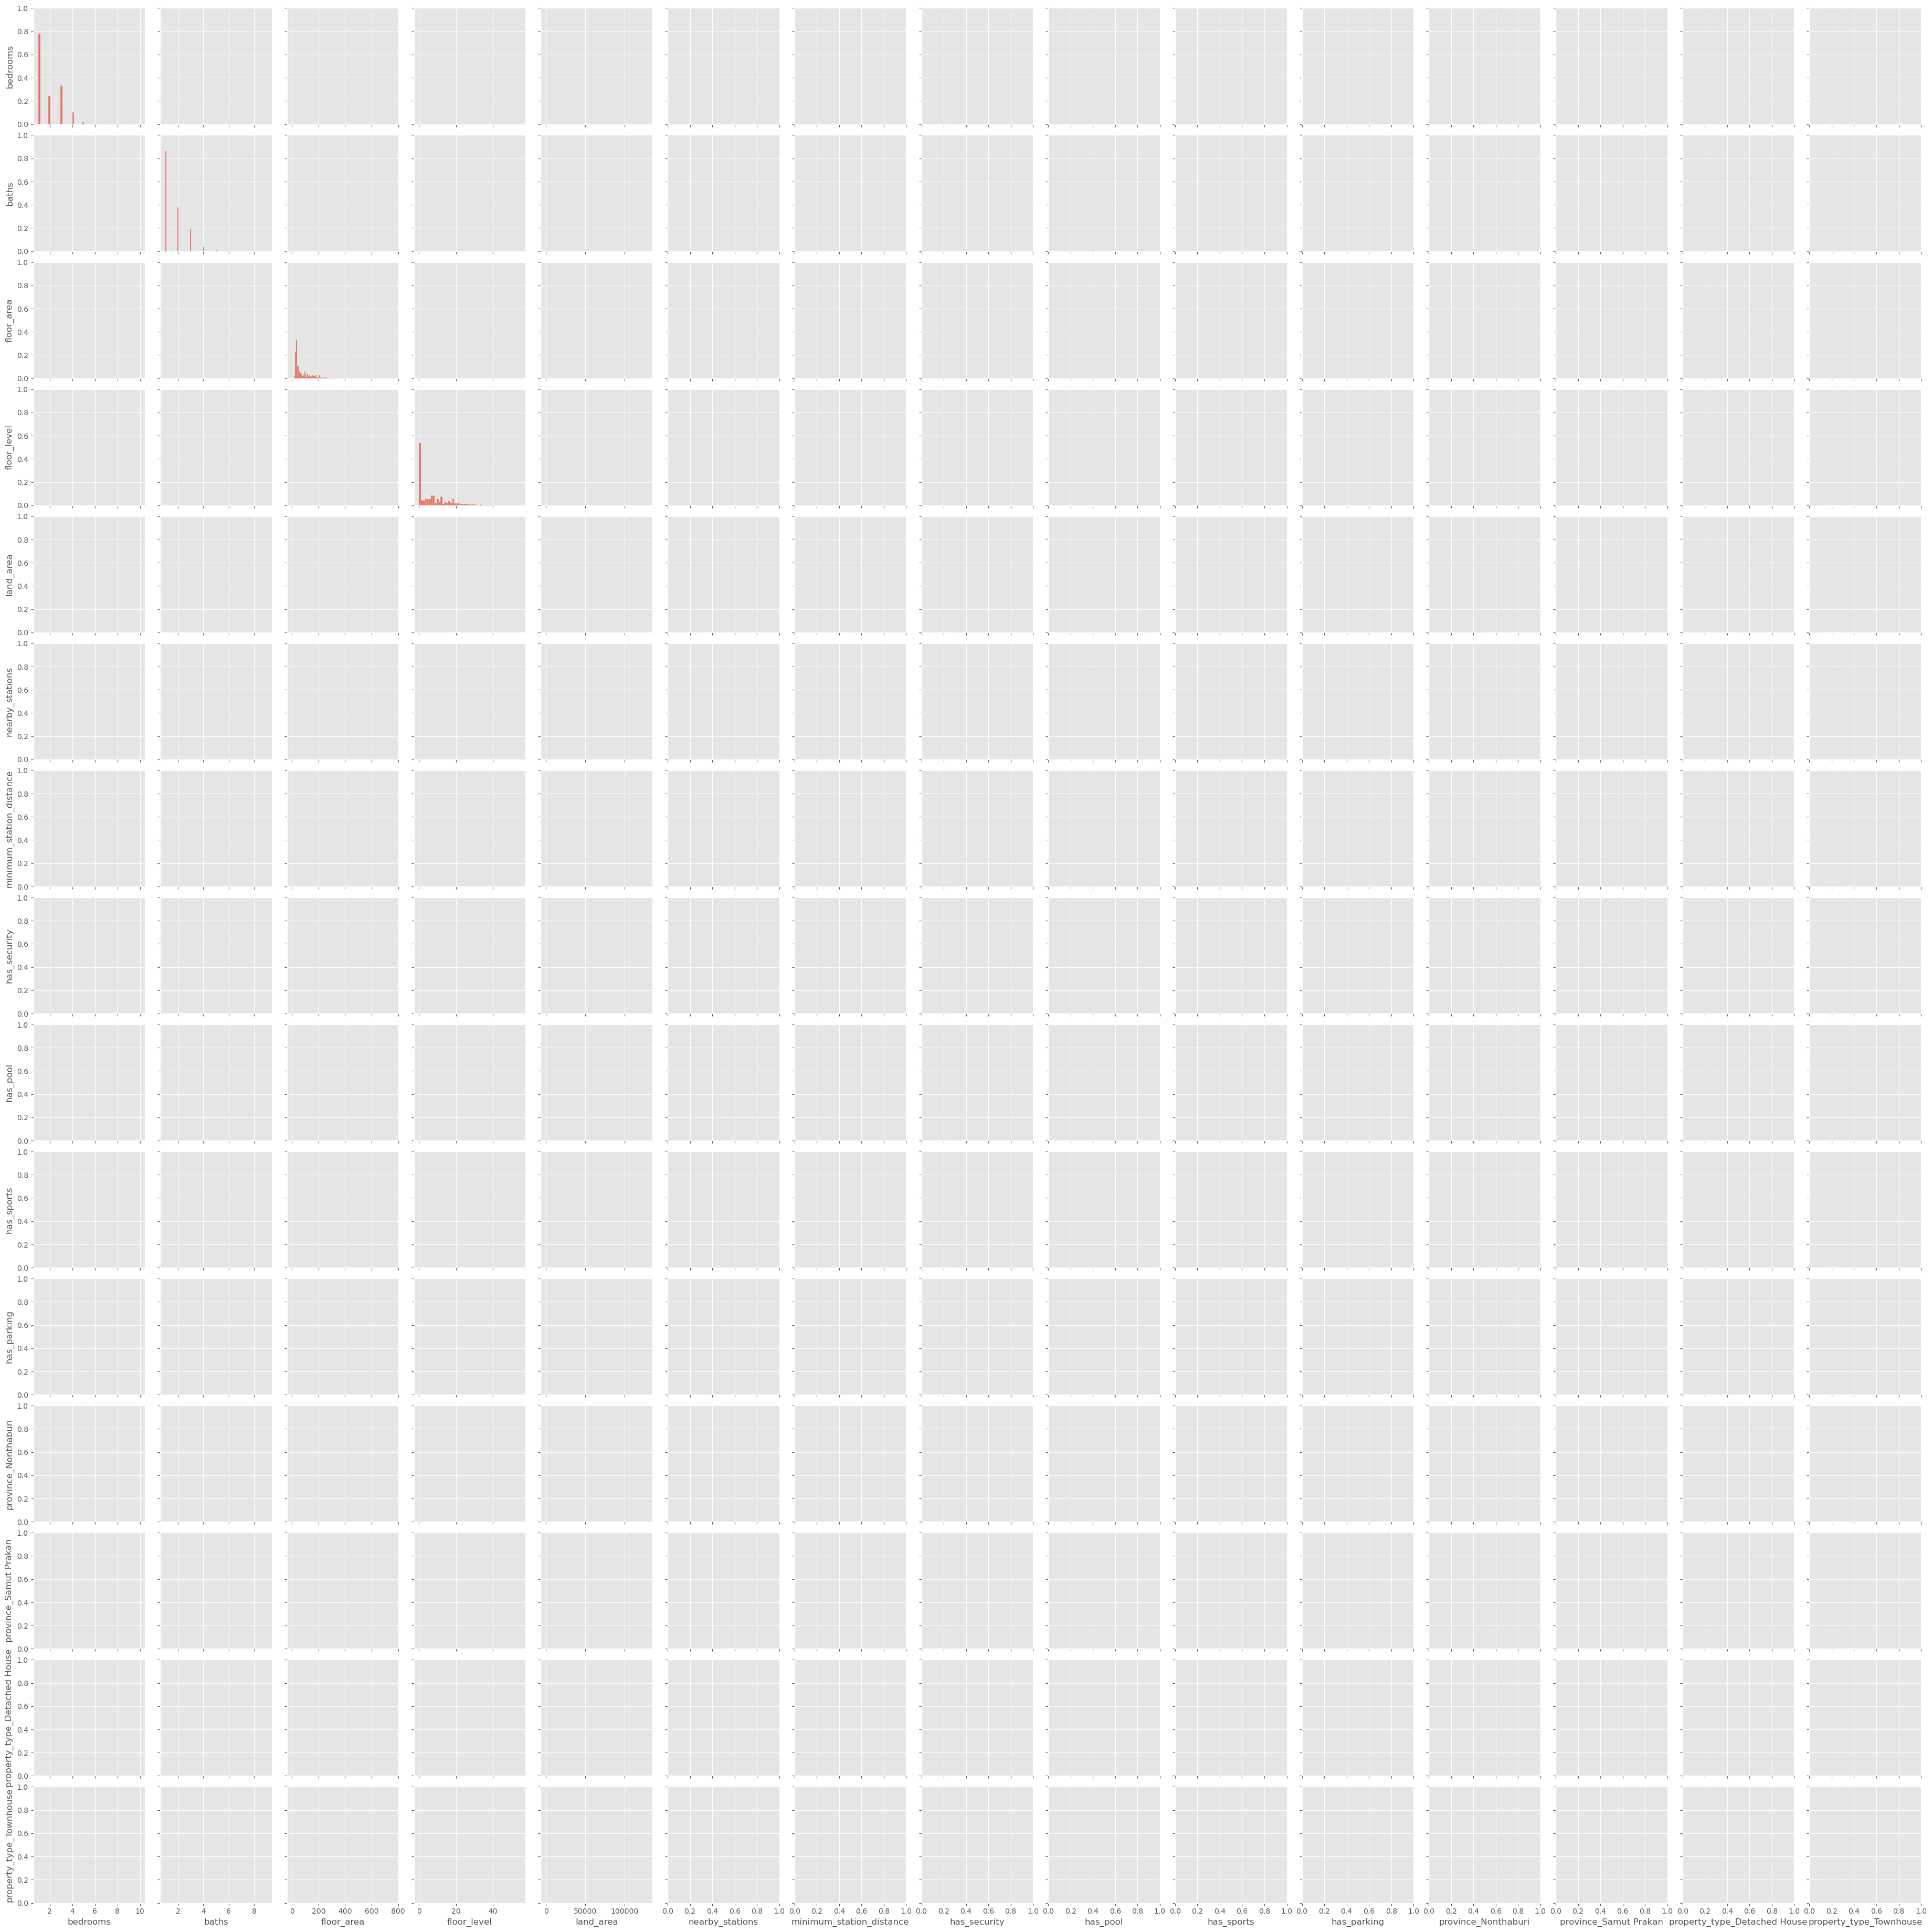

In [53]:
sns.pairplot(X_train);